Please upload Employee_Salary_Dataset.csv or archive.zip


Saving archive.zip to archive.zip

Uploaded file: archive.zip

ZIP file detected. Extracting...
CSV file found: extracted_data/Employee_Salary_Dataset.csv

================ DATASET LOADED ================

First 5 Rows:
   ID  Experience_Years  Age  Gender  Salary
0   1                 5   28  Female  250000
1   2                 1   21    Male   50000
2   3                 3   23  Female  170000
3   4                 2   22    Male   25000
4   5                 1   17    Male   10000

Dataset Shape:
(35, 5)

Column Names:
['ID', 'Experience_Years', 'Age', 'Gender', 'Salary']

================ DATASET INFORMATION ================

Data Types:
ID                   int64
Experience_Years     int64
Age                  int64
Gender              object
Salary               int64
dtype: object

Statistical Summary:
              ID  Experience_Years        Age        Salary
count  35.000000          35.00000  35.000000  3.500000e+01
mean   18.000000           9.20000  35.485714  2.059147e+0

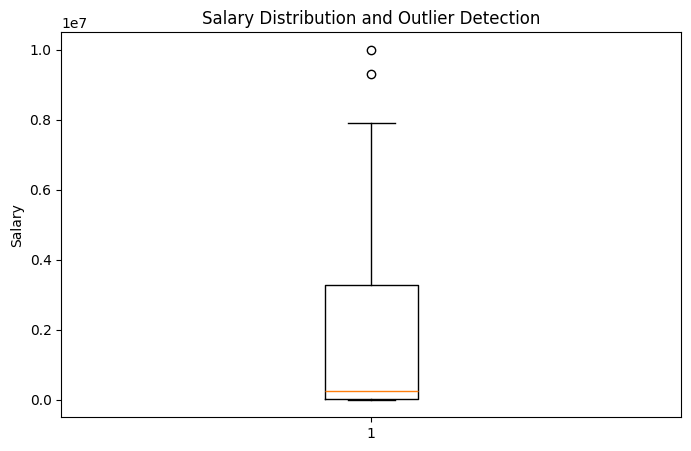

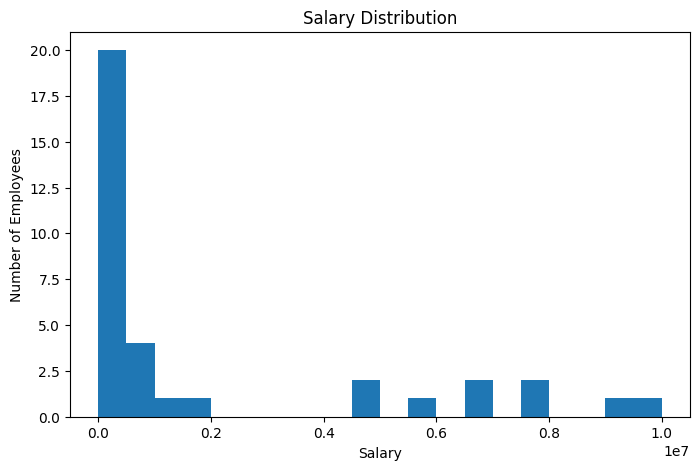


================ NORMALIZATION ================

Original and Normalized Salary:
   Salary_Original  Salary_Normalized
0           250000           0.024707
1            50000           0.004701
2           170000           0.016705
3            25000           0.002201
4            10000           0.000700
5          5001000           0.499950
6           800000           0.079724
7             9000           0.000600
8            61500           0.005852
9           650000           0.064719

================ LABEL ENCODING ================

Gender Encoding:
   Gender  Gender_Encoded
0  Female               0
1    Male               1

================ ONE-HOT ENCODING ================

One-Hot Encoded Gender:
   Gender_Female  Gender_Male
0           True        False
1          False         True
2           True        False
3          False         True
4          False         True

================ FINAL CLEANED DATASET ================
   ID  Experience_Years  Age  Gender  Sa

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


     EXPERIMENT 3 COMPLETED SUCCESSFULLY

Techniques Performed:
1. Missing Value Detection
2. Missing Value Handling
3. Duplicate Detection
4. Duplicate Removal
5. Outlier Detection using IQR
6. Outlier Visualization using Boxplot
7. Salary Distribution Visualization
8. Min-Max Normalization
9. Label Encoding
10. One-Hot Encoding

Original Dataset Shape:
(35, 10)

Final Dataset Shape:
(35, 10)

Cleaned Dataset:
Employee_Salary_Cleaned_Transformed.csv

        EDA AND DATA TRANSFORMATION DONE


In [1]:
# ============================================================
# EXPERIMENT 3
# EXPLORATORY DATA ANALYSIS (EDA)
# DATA CLEANING AND DATA TRANSFORMATION
# ============================================================

# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import glob

from google.colab import files

from sklearn.preprocessing import MinMaxScaler, LabelEncoder


# ============================================================
# 2. UPLOAD DATASET
# ============================================================

print("Please upload Employee_Salary_Dataset.csv or archive.zip")

uploaded = files.upload()

uploaded_file = list(uploaded.keys())[0]

print("\nUploaded file:", uploaded_file)


# ============================================================
# 3. FIND CSV FILE
# ============================================================

if uploaded_file.lower().endswith(".zip"):

    print("\nZIP file detected. Extracting...")

    with zipfile.ZipFile(uploaded_file, "r") as zip_ref:
        zip_ref.extractall("extracted_data")

    csv_files = glob.glob(
        "extracted_data/**/*.csv",
        recursive=True
    )

    if len(csv_files) == 0:
        raise FileNotFoundError(
            "No CSV file found inside the ZIP file."
        )

    csv_file = csv_files[0]

    print("CSV file found:", csv_file)

elif uploaded_file.lower().endswith(".csv"):

    csv_file = uploaded_file

else:

    raise ValueError(
        "Please upload a CSV or ZIP file."
    )


# ============================================================
# 4. LOAD DATASET
# ============================================================

df = pd.read_csv(csv_file)

print("\n================ DATASET LOADED ================")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


# ============================================================
# 5. DATASET INFORMATION
# ============================================================

print("\n================ DATASET INFORMATION ================")

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())


# ============================================================
# 6. IDENTIFY MISSING VALUES
# ============================================================

print("\n================ MISSING VALUES ================")

print("\nMissing Values Table:")
print(df.isnull())

print("\nMissing Values Count:")
print(df.isnull().sum())


# ============================================================
# 7. HANDLE MISSING VALUES
# ============================================================

print("\n================ HANDLING MISSING VALUES ================")

# Fill numerical missing values with mean

if df["Age"].isnull().sum() > 0:

    df["Age"] = df["Age"].fillna(
        df["Age"].mean()
    )

if df["Experience_Years"].isnull().sum() > 0:

    df["Experience_Years"] = df["Experience_Years"].fillna(
        df["Experience_Years"].mean()
    )

if df["Salary"].isnull().sum() > 0:

    df["Salary"] = df["Salary"].fillna(
        df["Salary"].mean()
    )


# Fill categorical missing values with mode

if df["Gender"].isnull().sum() > 0:

    df["Gender"] = df["Gender"].fillna(
        df["Gender"].mode()[0]
    )


print("Missing values handled successfully.")

print("\nMissing Values After Handling:")
print(df.isnull().sum())


# ============================================================
# 8. IDENTIFY DUPLICATE RECORDS
# ============================================================

print("\n================ DUPLICATE RECORDS ================")

print("Duplicate records before removal:")

print(df.duplicated())

print(
    "\nTotal duplicate records:",
    df.duplicated().sum()
)


# ============================================================
# 9. REMOVE DUPLICATE RECORDS
# ============================================================

df.drop_duplicates(
    inplace=True
)

print("\nDuplicate records removed successfully.")

print(
    "Total records after removing duplicates:",
    len(df)
)


# ============================================================
# 10. DETECT OUTLIERS USING IQR
# ============================================================

print("\n================ OUTLIER DETECTION ================")

# Salary outliers

Q1 = df["Salary"].quantile(0.25)

Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR


print("Q1:", Q1)

print("Q3:", Q3)

print("IQR:", IQR)

print("Lower Limit:", lower_limit)

print("Upper Limit:", upper_limit)


# Identify salary outliers

outliers = df[
    (df["Salary"] < lower_limit) |
    (df["Salary"] > upper_limit)
]


print("\nSalary Outliers:")

print(outliers)

print(
    "\nNumber of Salary Outliers:",
    len(outliers)
)


# ============================================================
# 11. OUTLIER VISUALIZATION - BOXPLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(
    df["Salary"]
)

plt.ylabel("Salary")

plt.title(
    "Salary Distribution and Outlier Detection"
)

plt.show()


# ============================================================
# 12. SALARY HISTOGRAM
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    df["Salary"],
    bins=20
)

plt.xlabel("Salary")

plt.ylabel("Number of Employees")

plt.title(
    "Salary Distribution"
)

plt.show()


# ============================================================
# 13. NORMALIZATION USING MIN-MAX SCALING
# ============================================================

print("\n================ NORMALIZATION ================")

# Create a copy of original salary
df["Salary_Original"] = df["Salary"]


# Create scaler
scaler = MinMaxScaler()


# Normalize Salary
df["Salary_Normalized"] = scaler.fit_transform(
    df[["Salary"]]
)


print("\nOriginal and Normalized Salary:")

print(
    df[
        [
            "Salary_Original",
            "Salary_Normalized"
        ]
    ].head(10)
)


# ============================================================
# 14. LABEL ENCODING
# ============================================================

print("\n================ LABEL ENCODING ================")

# Create Label Encoder
encoder = LabelEncoder()


# Encode Gender
df["Gender_Encoded"] = encoder.fit_transform(
    df["Gender"]
)


print("\nGender Encoding:")

print(
    df[
        [
            "Gender",
            "Gender_Encoded"
        ]
    ].drop_duplicates()
)


# ============================================================
# 15. ONE-HOT ENCODING
# ============================================================

print("\n================ ONE-HOT ENCODING ================")

# Create one-hot encoded columns
gender_one_hot = pd.get_dummies(
    df["Gender"],
    prefix="Gender"
)


print("\nOne-Hot Encoded Gender:")

print(gender_one_hot.head())


# ============================================================
# 16. COMBINE ONE-HOT ENCODING WITH DATASET
# ============================================================

df = pd.concat(
    [
        df,
        gender_one_hot
    ],
    axis=1
)


# ============================================================
# 17. DISPLAY FINAL TRANSFORMED DATASET
# ============================================================

print("\n================ FINAL CLEANED DATASET ================")

print(df.head())

print("\nFinal Dataset Shape:")

print(df.shape)


# ============================================================
# 18. FINAL MISSING VALUE CHECK
# ============================================================

print("\n================ FINAL MISSING VALUE CHECK ================")

print(df.isnull().sum())


# ============================================================
# 19. FINAL DUPLICATE CHECK
# ============================================================

print("\n================ FINAL DUPLICATE CHECK ================")

print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)


# ============================================================
# 20. SAVE CLEANED DATASET
# ============================================================

output_file = "Employee_Salary_Cleaned_Transformed.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nCleaned and transformed dataset saved as:")

print(output_file)


# ============================================================
# 21. DOWNLOAD CLEANED DATASET
# ============================================================

files.download(
    output_file
)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n====================================================")
print("     EXPERIMENT 3 COMPLETED SUCCESSFULLY")
print("====================================================")

print("\nTechniques Performed:")

print("1. Missing Value Detection")
print("2. Missing Value Handling")
print("3. Duplicate Detection")
print("4. Duplicate Removal")
print("5. Outlier Detection using IQR")
print("6. Outlier Visualization using Boxplot")
print("7. Salary Distribution Visualization")
print("8. Min-Max Normalization")
print("9. Label Encoding")
print("10. One-Hot Encoding")

print("\nOriginal Dataset Shape:")
print(df.shape)

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nCleaned Dataset:")
print("Employee_Salary_Cleaned_Transformed.csv")

print("\n====================================================")
print("        EDA AND DATA TRANSFORMATION DONE")
print("====================================================")